In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pickle

In [44]:
#importing the dataset
path = "C:/Users/USER/Documents/PROJECT/survey lung cancer.csv"
df = pd.read_csv(path)
df


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [45]:
df.info

<bound method DataFrame.info of     GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC_DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL_CONSUMING  \
0                  1         2         1         2                  2   
1    

In [46]:
#df.isna()
df.isna().head(1)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [47]:
df.isna().sum().to_frame().T.style.set_properties(**{"background-color": "white","color":"blue","border": "0.5px  solid black"})

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [48]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [49]:
df.describe(include=object).T.style.set_properties(**{"background-color": "white","color":"blue","border": "1.5px  black"})

,count,unique,top,freq
GENDER,309,2,M,162
LUNG_CANCER,309,2,YES,270


In [50]:
#The corr() function displays the correlation between different variables in our dataset
df.corr()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
AGE,1.000000,-0.084475,0.005205,0.053170,0.018685,-0.012642,0.012614,0.027990,0.055011,0.058985,0.169950,-0.017513,-0.001270,-0.018104
SMOKING,-0.084475,1.000000,-0.014585,0.160267,-0.042822,-0.141522,-0.029575,0.001913,-0.129426,-0.050623,-0.129471,0.061264,0.030718,0.120117
YELLOW_FINGERS,0.005205,-0.014585,1.000000,0.565829,0.323083,0.041122,-0.118058,-0.144300,-0.078515,-0.289025,-0.012640,-0.105944,0.345904,-0.104829
ANXIETY,0.053170,0.160267,0.565829,1.000000,0.216841,-0.009678,-0.188538,-0.165750,-0.191807,-0.165750,-0.225644,-0.144077,0.489403,-0.113634
PEER_PRESSURE,0.018685,-0.042822,0.323083,0.216841,1.000000,0.048515,0.078148,-0.081800,-0.068771,-0.159973,-0.089019,-0.220175,0.366590,-0.094828
CHRONIC_DISEASE,-0.012642,-0.141522,0.041122,-0.009678,0.048515,1.000000,-0.110529,0.106386,-0.049967,0.002150,-0.175287,-0.026459,0.075176,-0.036938
FATIGUE,0.012614,-0.029575,-0.118058,-0.188538,0.078148,-0.110529,1.000000,0.003056,0.141937,-0.191377,0.146856,0.441745,-0.132790,-0.010832
ALLERGY,0.027990,0.001913,-0.144300,-0.165750,-0.081800,0.106386,0.003056,1.000000,0.173867,0.344339,0.189524,-0.030056,-0.061508,0.239433
WHEEZING,0.055011,-0.129426,-0.078515,-0.191807,-0.068771,-0.049967,0.141937,0.173867,1.000000,0.265659,0.374265,0.037834,0.069027,0.147640
ALCOHOL_CONSUMING,0.058985,-0.050623,-0.289025,-0.165750,-0.159973,0.002150,-0.191377,0.344339,0.265659,1.000000,0.202720,-0.179416,-0.009294,0.331226


In [51]:
dff = df[df.duplicated()].shape[0]
dff

33

In [52]:
df1 = df
df2=df1.drop_duplicates()
df2

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,F,59,1,2,2,2,1,1,2,2,1,2,1,2,1,YES
280,F,59,2,1,1,1,2,2,2,1,1,1,2,1,1,NO
281,M,55,2,1,1,1,1,2,2,1,1,1,2,1,2,NO
282,M,46,1,2,2,1,1,1,1,1,1,1,1,2,2,NO


In [53]:
duplicate = df[df1.duplicated()].shape[0]
print(f"There are {duplicate} duplicate entries among {df1.shape[0]} entries in this dataset.")

df1.drop_duplicates(keep='first',inplace=True)
print(f"\nAfter removing duplicate entries there are {df1.shape[0]} entries in this dataset.")

There are 33 duplicate entries among 309 entries in this dataset.

After removing duplicate entries there are 276 entries in this dataset.


In [54]:
#data_temp = data.copy()
df2["GENDER"] = df2["GENDER"].replace({"M" : "Male" , "F" : "Female"})

for column in df2:
    df2[column] = df2[column].replace({2: "Yes" , 1 : "No"})
for column in df2:
   df2[column] = df2[column].replace({"Yes" : 1, "No": 0})
df2.head().style.set_properties(**{"background-color": "white","color":"black","border": "1.5px  solid black"})    

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,Male,69,0,1,1,0,0,1,0,1,1,1,1,1,1,YES
1,Male,74,1,0,0,0,1,1,1,0,0,0,1,1,1,YES
2,Female,59,0,0,0,1,0,1,0,1,0,1,1,0,1,NO
3,Male,63,1,1,1,0,0,0,0,0,1,0,0,1,1,NO
4,Female,63,0,1,0,0,0,0,0,1,0,1,1,0,0,NO


In [55]:
#adding biomarkers to the dataset randomly
Biomarker= ['bTMB', 'EGFR', 'ALK', 'cfDNA' , 'ESO']
df2['Biomarker'] =np.where(df2['LUNG_CANCER']!= 'NO', np.random.choice(Biomarker, size=len(df2)), 'Nil')

    
#df2['Biomarker'] = np.random.choice(Biomarker, size=len(df2))
cols = df2.columns.tolist()
cols.insert(-1, cols.pop(cols.index('Biomarker')))
df3 = df2[cols]
print("Data Preview:")
display(df3.head(6))
print("\nLast Six Rows of the Data:")
display(df3.tail(6))

Data Preview:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,Biomarker,LUNG_CANCER
0,Male,69,0,1,1,0,0,1,0,1,1,1,1,1,1,ESO,YES
1,Male,74,1,0,0,0,1,1,1,0,0,0,1,1,1,bTMB,YES
2,Female,59,0,0,0,1,0,1,0,1,0,1,1,0,1,Nil,NO
3,Male,63,1,1,1,0,0,0,0,0,1,0,0,1,1,Nil,NO
4,Female,63,0,1,0,0,0,0,0,1,0,1,1,0,0,Nil,NO
5,Female,75,0,1,0,0,1,1,1,1,0,1,1,0,0,ESO,YES



Last Six Rows of the Data:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,Biomarker,LUNG_CANCER
278,Female,77,1,1,1,1,1,1,0,0,0,0,1,1,0,ESO,YES
279,Female,59,0,1,1,1,0,0,1,1,0,1,0,1,0,ALK,YES
280,Female,59,1,0,0,0,1,1,1,0,0,0,1,0,0,Nil,NO
281,Male,55,1,0,0,0,0,1,1,0,0,0,1,0,1,Nil,NO
282,Male,46,0,1,1,0,0,0,0,0,0,0,0,1,1,Nil,NO
283,Male,60,0,1,1,0,0,1,0,1,1,1,1,1,1,bTMB,YES


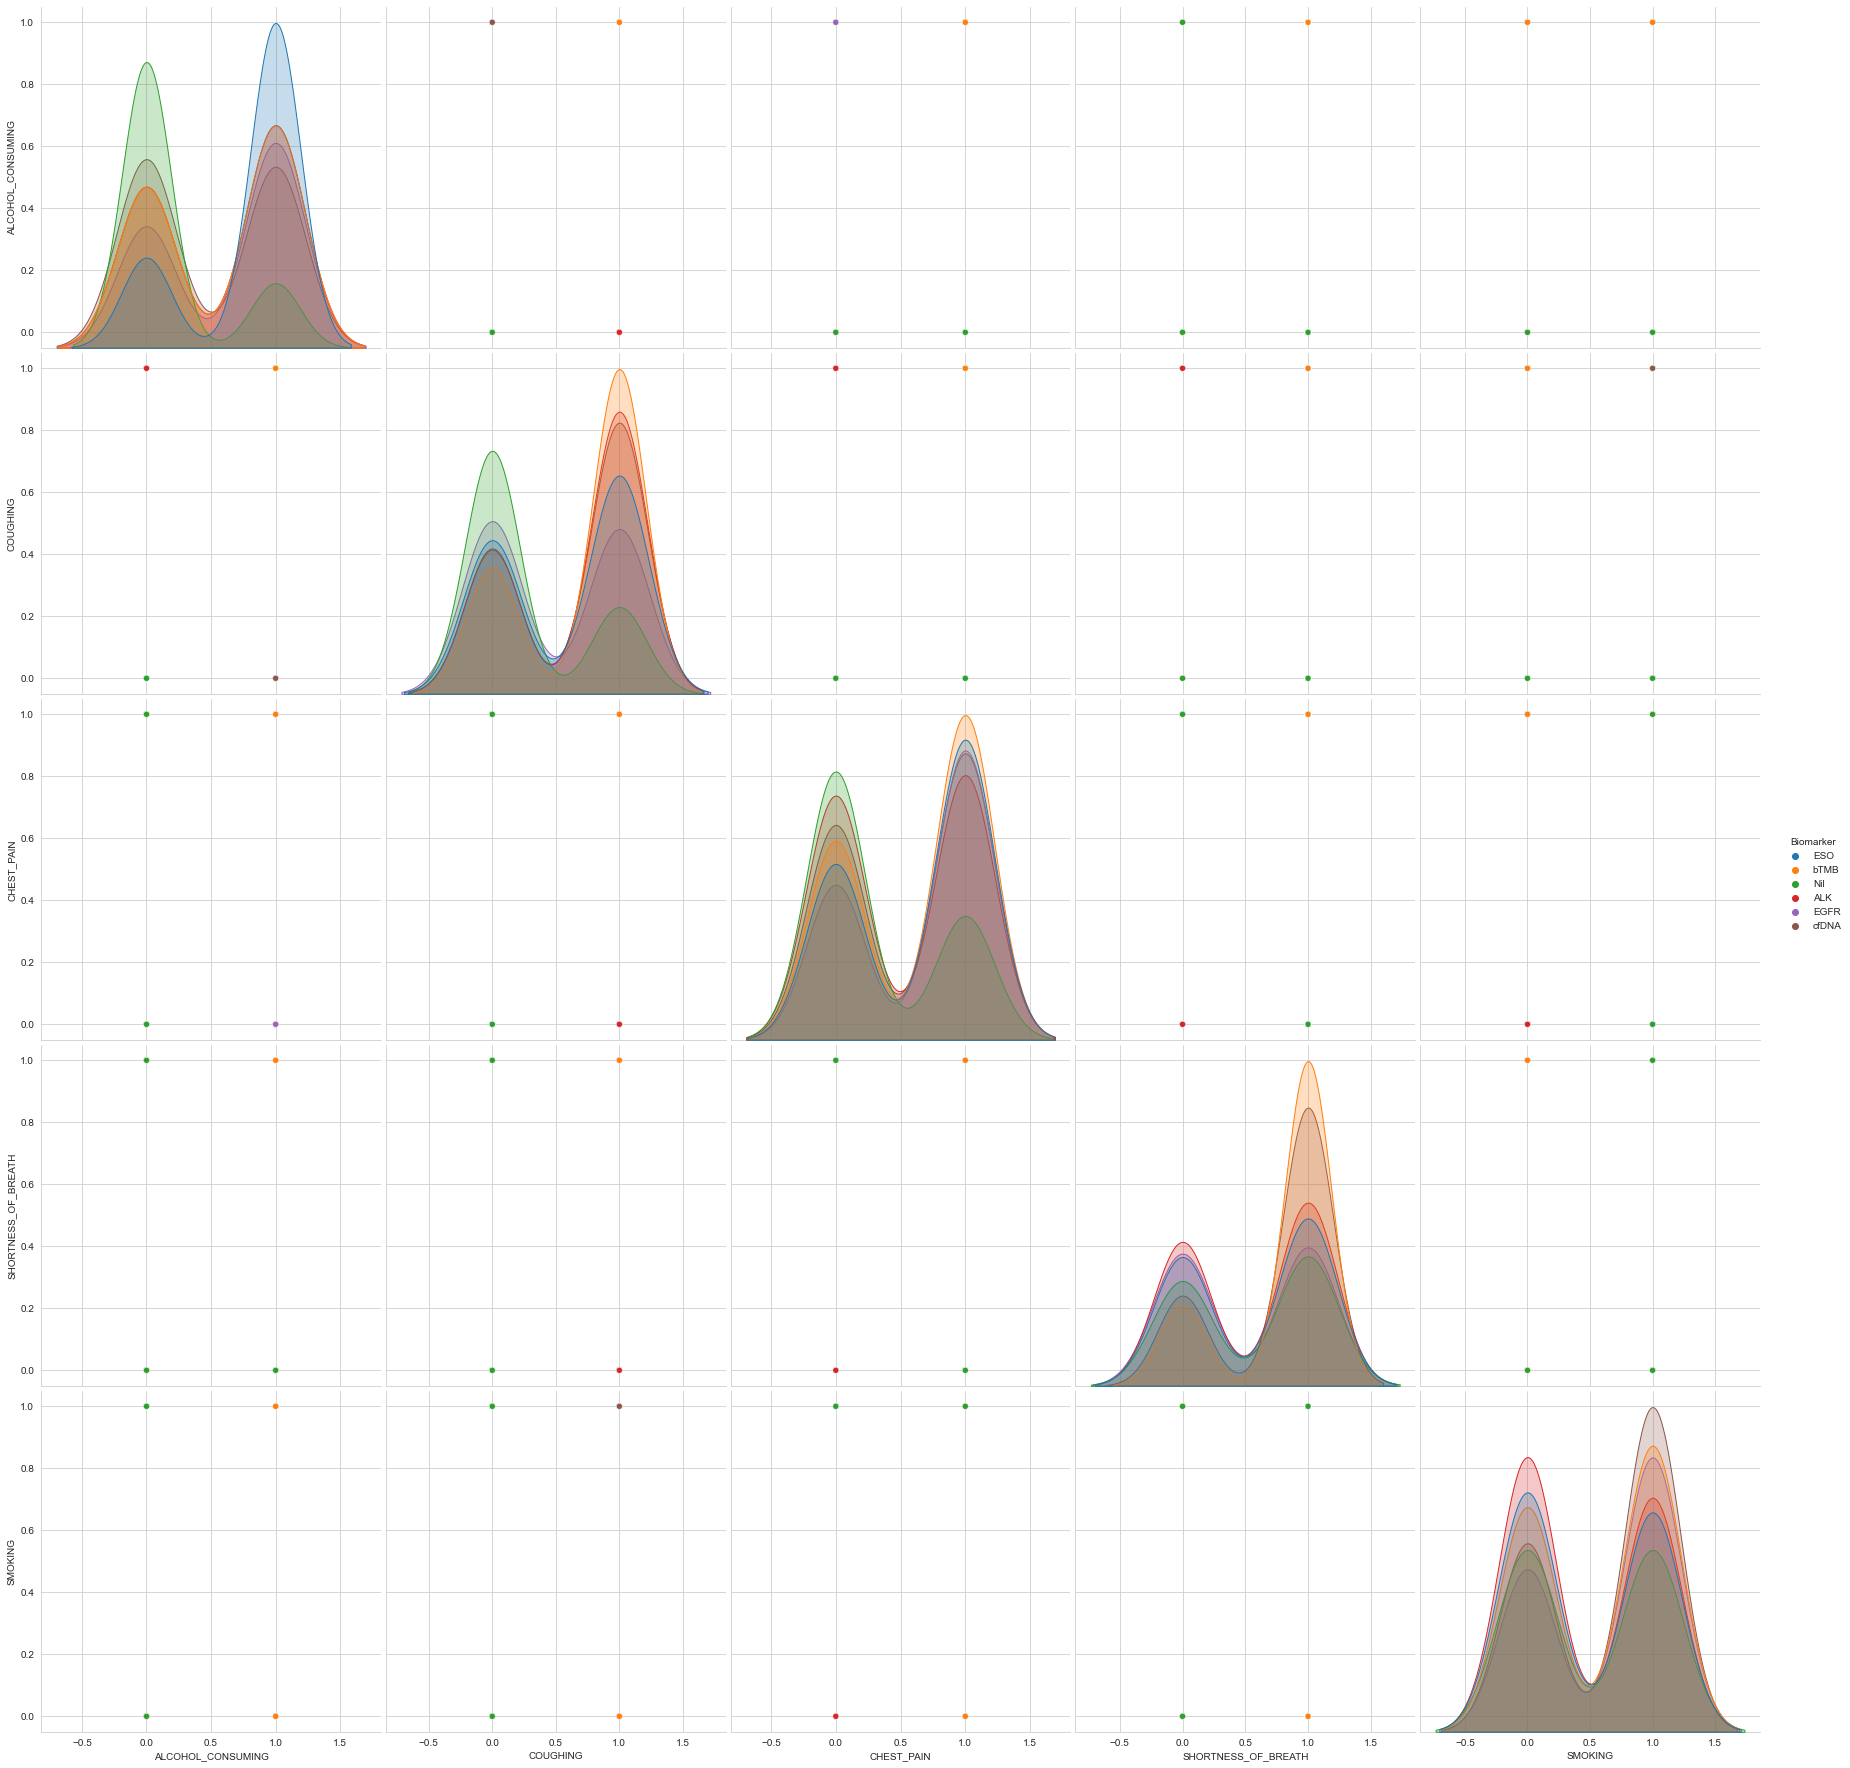

In [56]:
#data visualization
sns.set_style('whitegrid') # plot stlye
#pair plot method
sns.pairplot(df3[['ALCOHOL_CONSUMING','COUGHING','CHEST_PAIN','Biomarker', 'SHORTNESS_OF_BREATH','SMOKING', 'GENDER']],
            hue = 'Biomarker',
             height = 5,)

<AxesSubplot:>

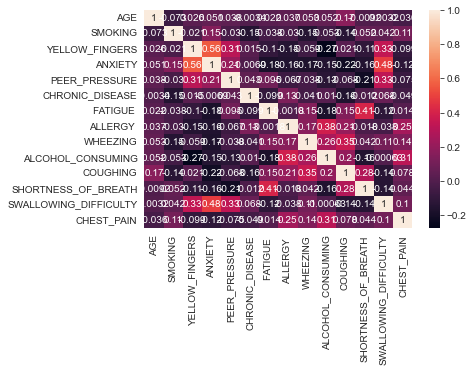

In [57]:
sns.heatmap(df3.corr(), annot = True)

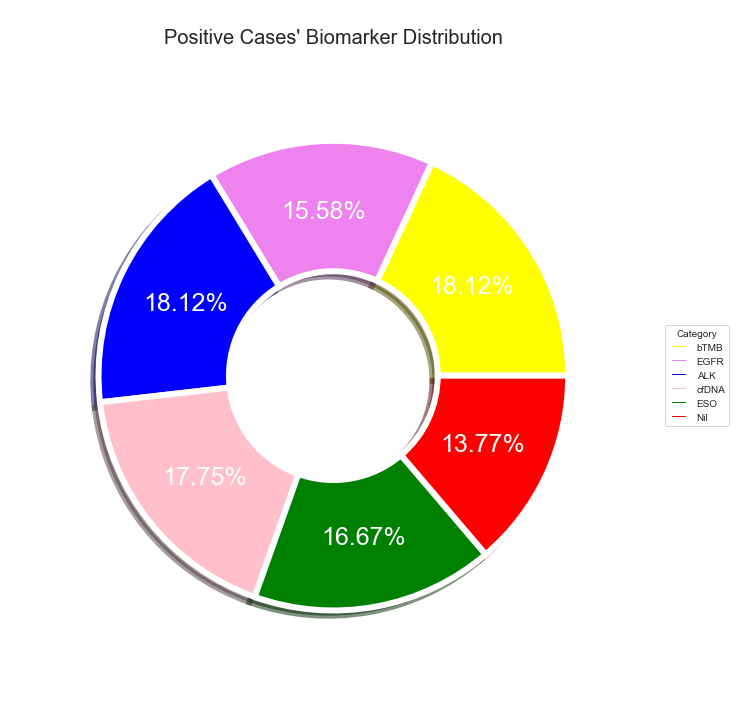

In [58]:
plt.subplots(figsize=(12, 12))

labels = 'bTMB', 'EGFR', 'ALK', 'cfDNA' , 'ESO', 'Nil'
size = 0.5
#Biomarker= ['bTMB', 'EGFR', 'ALK', 'cfDNA' , 'ESO']


wedges, texts, autotexts = plt.pie([len(df3[df3["Biomarker"]=="bTMB"]["Biomarker"]),
                                    len(df3[df3["Biomarker"]=="EGFR"]["Biomarker"]),
                                    len(df3[df3["Biomarker"]=="ALK"]["Biomarker"]),
                                    len(df3[df3["Biomarker"]=="cfDNA"]["Biomarker"]),
                                    len(df3[df3["Biomarker"]=="ESO"]["Biomarker"]),
                                    len(df3[df3["Biomarker"]=="Nil"]["Biomarker"])],
                                    explode = (0,0,0,0,0,0),
                                    textprops=dict(size= 25, color= "white"),
                                    autopct="%.2f%%", 
                                    pctdistance = 0.7,
                                    radius=.9, 
                                    colors = ["yellow","violet", "blue", "pink", "green","red"], 
                                    shadow = True,
                                    wedgeprops=dict(width = size, edgecolor = "white", 
                                    linewidth = 6),
                                    startangle = 0)

plt.legend(wedges, labels, title="Category",loc="center left",bbox_to_anchor=(1, 0, 0.8, 1))
plt.title("\nPositive Cases' Biomarker Distribution",fontsize=20)
plt.show()

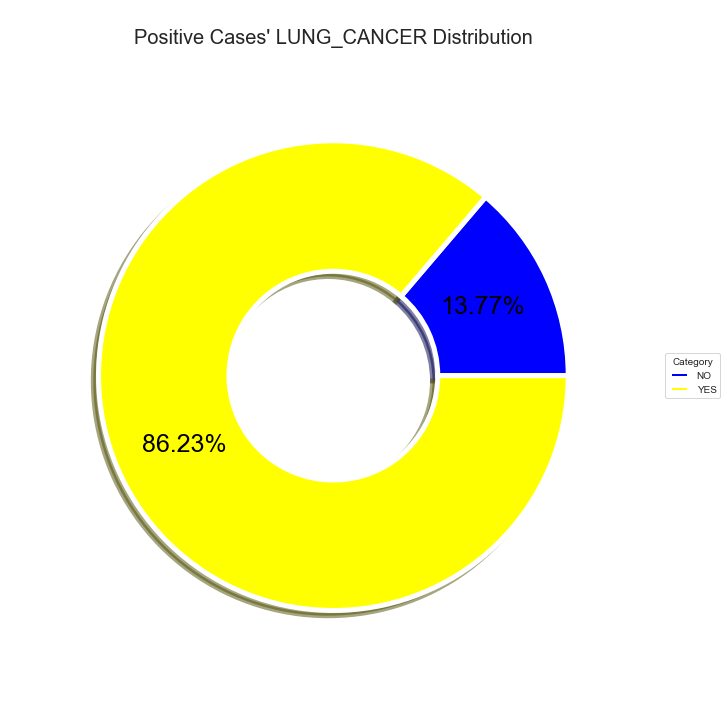

In [59]:
plt.subplots(figsize=(12, 12))

labels = "NO","YES"
size = 0.5

wedges, texts, autotexts = plt.pie([len(df3[df3["LUNG_CANCER"]=="NO"]["LUNG_CANCER"]),
                                    len(df3[df3["LUNG_CANCER"]=="YES"]["LUNG_CANCER"])],
                                    explode = (0,0),
                                    textprops=dict(size= 25, color= "black"),
                                    autopct="%.2f%%", 
                                    pctdistance = 0.7,
                                    radius=.9, 
                                    colors = ["blue","yellow"], 
                                    shadow = True,
                                    wedgeprops=dict(width = size, edgecolor = "white", 
                                    linewidth = 5),
                                    startangle = 0)

plt.legend(wedges, labels, title="Category",loc="center left",bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("\nPositive Cases' LUNG_CANCER Distribution",fontsize=20)
plt.show()

In [60]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [61]:
X= df3.iloc[:,1:15]   #all features
Y= df3.iloc[:,-1]   #target output (Biomarkers)
best_features= SelectKBest(score_func=chi2, k=3)
fit= best_features.fit(X,Y)
df_scores= pd.DataFrame(fit.scores_)
df_columns= pd.DataFrame(X.columns)

In [62]:
# for traing and testing of the model
x_train, x_test, y_train, y_test =train_test_split(X,Y, test_size=0.3, random_state =40)
#for validation of the model
x_val, x_v_test, y_val, y_v_test =train_test_split(x_test,y_test, test_size=0.5, random_state =42) 

In [63]:
X.shape

(276, 14)

In [64]:
Y.shape

(276,)

In [65]:
x_test

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
65,71,1,1,1,1,1,1,0,1,0,1,0,1,1
18,68,1,1,1,1,1,1,0,0,0,1,1,0,0
102,64,1,0,0,0,0,1,1,1,1,1,1,0,1
157,57,1,1,0,1,0,0,0,0,0,0,0,0,1
179,72,1,1,1,1,0,1,0,1,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,71,1,1,1,0,1,0,0,1,1,0,1,1,1
135,69,0,0,1,0,0,1,0,1,1,1,1,1,0
90,62,0,0,0,1,0,0,0,1,1,0,0,1,1
241,59,1,0,0,0,0,1,1,1,1,1,1,0,1


In [66]:
x_test.shape

(83, 14)

In [67]:
y_test.shape

(83,)

In [68]:
y_train

191    YES
114    YES
28     YES
81     YES
248    YES
      ... 
276    YES
196    YES
168    YES
7      YES
225    YES
Name: LUNG_CANCER, Length: 193, dtype: object

In [69]:
x_train.shape

(193, 14)

In [70]:
y_train.shape

(193,)

In [71]:
# freature scaling
from sklearn.preprocessing import StandardScaler
x_train = StandardScaler().fit_transform(x_train)
x_test = StandardScaler().fit_transform(x_test)

In [72]:
def models(x_train, y_train):
    #creating a ramdom forest
    from sklearn.ensemble import RandomForestClassifier
    forest = RandomForestClassifier(random_state = 0, criterion = "entropy", n_estimators = 10)
    forest.fit(x_train,y_train)
    
#for accuracy
    print('Random Forest accuracy: ', forest.score(x_train,y_train))
    
    
    return  forest
    

In [73]:
model = models(x_train,y_train)

Random Forest accuracy:  0.9896373056994818


In [74]:
#testing the model and result and validation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(model)
print(classification_report(y_test, model.predict(x_test)))
print("Accuracy : ", accuracy_score(y_test, model.predict(x_test)))

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)
              precision    recall  f1-score   support

          NO       0.70      0.58      0.64        12
         YES       0.93      0.96      0.94        71

    accuracy                           0.90        83
   macro avg       0.82      0.77      0.79        83
weighted avg       0.90      0.90      0.90        83

Accuracy :  0.9036144578313253


In [75]:
#predicting the random forest

pred= model.predict(x_test)
print("the predicted value: ")
print(pred)
print('the actual value')
print(y_test)

the predicted value: 
['YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'NO' 'YES' 'YES' 'NO'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO']
the actual value
65     YES
18     YES
102    YES
157     NO
179    YES
      ... 
246    YES
135    YES
90     YES
241    YES
193    YES
Name: LUNG_CANCER, Length: 83, dtype: object


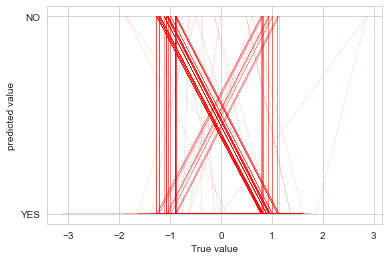

In [76]:
plt.plot(x_test, pred, color='red', linewidth=0.1)
plt.xlabel('True value')
plt.ylabel('predicted value')
#plt.xticks(())
#plt.yticks(())
plt.show()

In [77]:
pre= model[1].predict(x_test)
print("the predicted value: ")
print(pre)
print('the actual value')
print(y_test)

the predicted value: 
[1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.
 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
the actual value
65     YES
18     YES
102    YES
157     NO
179    YES
      ... 
246    YES
135    YES
90     YES
241    YES
193    YES
Name: LUNG_CANCER, Length: 83, dtype: object


In [78]:
x_test.shape

(83, 14)

In [79]:
y_test.shape

(83,)

In [80]:
# to save the model
filename = "LungCancer model"
pickle.dump(model,open(filename, "wb"))
print("model successsfully save")

#to load the model
load_model = pickle.load(open(filename, "rb"))
load_model

model successsfully save


RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [81]:
import joblib
joblib.dump(model, "Lung_Cancer.joblib")
print("model save")

load_model = joblib.load("lung_cancer.joblib")
load_model

model save


RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [82]:
#making prediction
pred_pickle = load_model.predict(x_test)
pred_joblib = load_model.predict(x_test)
print("pred_pickle: ", pred_pickle)
print("pred_joblib: ", pred_joblib)

pred_pickle:  ['YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'NO' 'YES' 'YES' 'NO'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO']
pred_joblib:  ['YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'NO' 'YES' 'YES' 'NO'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES

In [83]:
#pip install fastapi 

In [2]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.
